# Lesson 04: Feed quality, mispricing and price filters
**Level:** intermediate → advanced

A bridge with **no price filters** (check `price_filters: NONE` in `data/reference/bridge_config.json`) streams
whatever its LPs send. This lesson does four things:
1. Detects **stale quotes** (S02: LP_B gold), **bad ticks** (S01: LP_C EURUSD) and **crossed books**.
2. Measures the damage: client trades executed at prices that were never really available.
3. Designs a **stale filter** and a **spike filter**.
4. **Replays** the day with the filters to prove what they would have prevented.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import analysis as A, plotting as P
P.setup()
pd.set_option("display.width", 200, "display.max_columns", 30)

msgs = A.load_fix_messages()
quotes = A.lp_quotes(msgs)
orders, deals = A.load_platform()
sym, cfg, audit, clients = A.load_reference()
PIP, CONTRACT = sym.pip_size.to_dict(), sym.contract_size.to_dict()
print("bridge filters:", cfg["routing"]["price_filters"], "| stale filter:", cfg["routing"]["stale_quote_filter"])

bridge filters: NONE | stale filter: NONE


## 1. A book that remembers quote ages
For every moment, keep each LP's latest bid/ask **and the time it was received**. Age = now − last update.
The function below is the heart of this lesson; filters are applied inside it.

In [2]:
def lp_state(quotes, symbol):
    """Per-LP latest bid, ask and last-update time on a common timeline (every update from any LP)."""
    q = quotes[quotes.symbol == symbol].sort_values("recv_time")
    times = q.recv_time.drop_duplicates()
    state = {}
    for lp, g in q.groupby("lp"):
        g = g.drop_duplicates("recv_time", keep="last").set_index("recv_time")
        aligned = g[["bid1", "ask1"]].reindex(times, method="ffill")
        aligned["updated"] = pd.Series(g.index, index=g.index).reindex(times, method="ffill")
        aligned["age_ms"] = (times.values - aligned.updated.values) / np.timedelta64(1, "ms")
        state[lp] = aligned
    return pd.concat(state, axis=1)

st = lp_state(quotes, "XAUUSD")
st.loc["2025-10-15 12:05:58":"2025-10-15 12:06:00"]

LP_A                                              LP_B                                              LP_C                                         
                            bid1     ask1                 updated  age_ms     bid1    ask1                 updated   age_ms     bid1     ask1                 updated  age_ms
recv_time                                                                                                                                                                    
2025-10-15 12:05:58.749  4090.99  4091.24 2025-10-15 12:05:57.500  1249.0  4088.17  4088.4 2025-10-15 12:04:59.687  59062.0  4091.23  4091.41 2025-10-15 12:05:58.749     0.0
2025-10-15 12:05:59.127  4090.99  4091.24 2025-10-15 12:05:57.500  1627.0  4088.17  4088.4 2025-10-15 12:04:59.687  59440.0  4091.24  4091.44 2025-10-15 12:05:59.127     0.0
2025-10-15 12:05:59.355  4091.27  4091.49 2025-10-15 12:05:59.355     0.0  4088.17  4088.4 2025-10-15 12:04:59.687  59668.0  4091.24  4091.44 2025-10-15 12:05:59.127   228.0
2025-10-15 12:06:00.284  4091.34  4091.57 2025-10-15 12:06:00.284     0.0  4088.17  4088.4 2025-10-15 12:04:59.687  60597.0  4091.24  4091.44 2025-10-15 12:05:59.127  1157.0
2025-10-15 12:06:00.303  4091.34  4091.57 2025-10-15 12:06:00.284    19.0  4088.17  4088.4 2025-10-15 12:04:59.687  60616.0  4091.37  4091.55 2025-10-15 12:06:00.303     0.0
2025-10-15 12:06:00.414  4091.34  4091.57 2025-10-15 12:06:00.284   130.0  4088.17  4088.4 2025-10-15 12:04:59.687  60727.0  4091.38  4091.56 2025-10-15 12:06:00.414     0.0
2025-10-15 12:06:00.780  4091.41  4091.63 2025-10-15 12:06:00.780     0.0  4088.17  4088.4 2025-10-15 12:04:59.687  61093.0  4091.38  4091.56 2025-10-15 12:06:00.414   366.0

Inside the S02 window, LP_B's gold quote is tens of seconds old while LP_A and LP_C are fresh, and LP_B's ask is
**below** the others' bids.

## 2. Stale quotes at the top of the book
What really hurts is a stale quote that is **the best price**, because that's what clients see and trade on.

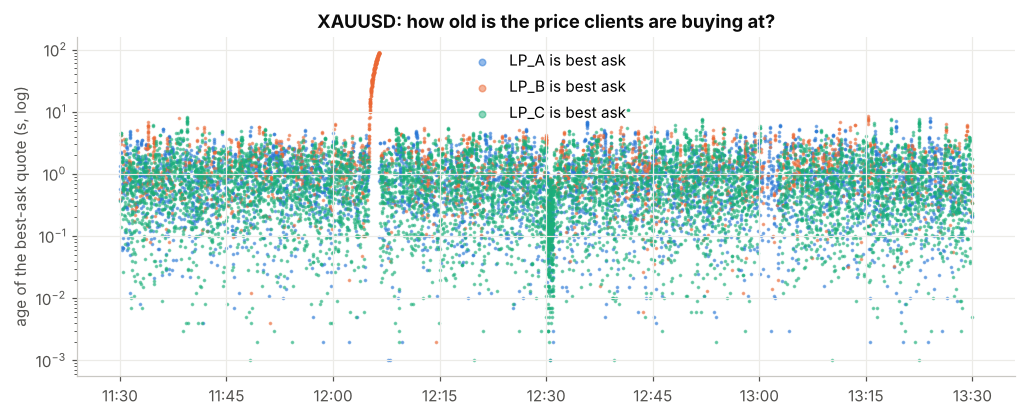

In [3]:
def best_with_age(st):
    lps = sorted({c[0] for c in st.columns})
    bids = pd.concat({lp: st[lp].bid1 for lp in lps}, axis=1)
    asks = pd.concat({lp: st[lp].ask1 for lp in lps}, axis=1)
    ages = pd.concat({lp: st[lp].age_ms for lp in lps}, axis=1)
    out = pd.DataFrame({"best_bid": bids.max(axis=1), "best_ask": asks.min(axis=1),
                        "bid_lp": bids.idxmax(axis=1), "ask_lp": asks.idxmin(axis=1)})
    out["ask_lp_age_ms"] = [ages.at[t, lp] for t, lp in zip(out.index, out.ask_lp)]
    out["bid_lp_age_ms"] = [ages.at[t, lp] for t, lp in zip(out.index, out.bid_lp)]
    return out

books = {s: best_with_age(lp_state(quotes, s)) for s in sym.index}
xau = books["XAUUSD"]
fig, ax = plt.subplots()
for lp in A.LPS:
    m = xau.ask_lp == lp
    ax.scatter(xau.index[m], xau.ask_lp_age_ms[m] / 1000, s=2, alpha=0.5, color=P.LP_COLORS[lp], label=f"{lp} is best ask")
ax.set_yscale("log"); ax.set_ylabel("age of the best-ask quote (s, log)")
ax.set_title("XAUUSD: how old is the price clients are buying at?"); P.time_axis(ax); ax.legend(markerscale=3); plt.show()

Normally the best price is under a few seconds old. Around **12:05–12:06:30**, LP_B's gold ask stays the best
price while it ages to **~90 seconds**. Around **13:00** LP_C does the same on the bid side (see the table below).
How old is "too old"?
Derive the threshold from the data rather than guessing:

In [4]:
intervals = quotes.groupby(["lp", "symbol"]).recv_time.diff().dt.total_seconds() * 1000
normal = intervals[intervals < 60_000]
print("normal update interval percentiles (ms):",
      {p: round(normal.quantile(p / 100)) for p in (50, 90, 99, 99.9)})
STALE_MS = 6000
print(f"-> stale threshold for this feed: {STALE_MS} ms "
      "(real LPs stream 10+ updates/s, where 500-1000 ms is typical)")

normal update interval percentiles (ms): {50: 667, 90: 2282, 99: 4553, 99.9: 6985}
-> stale threshold for this feed: 6000 ms (real LPs stream 10+ updates/s, where 500-1000 ms is typical)


In [5]:
stale_rows = []
for s, b in books.items():
    for side in ("bid", "ask"):
        m = b[f"{side}_lp_age_ms"] > STALE_MS
        if m.any():
            g = (m != m.shift()).cumsum()[m]
            for _, idx in g.groupby(g).groups.items():
                seg = b.loc[idx]
                stale_rows.append(dict(symbol=s, side=side, lp=seg[f"{side}_lp"].iloc[0], start=idx[0], end=idx[-1],
                                       max_age_s=round(seg[f"{side}_lp_age_ms"].max() / 1000, 1), updates=len(idx)))
stale = pd.DataFrame(stale_rows).sort_values("start")
stale[stale.max_age_s > 15]

,symbol,side,lp,start,end,max_age_s,updates
92,XAUUSD,ask,LP_B,2025-10-15 12:05:05.755,2025-10-15 12:06:29.968,90.3,182
41,GBPUSD,bid,LP_C,2025-10-15 13:00:05.067,2025-10-15 13:00:19.174,21.0,26
79,XAUUSD,bid,LP_C,2025-10-15 13:00:05.803,2025-10-15 13:02:31.923,152.9,284
26,EURUSD,ask,LP_C,2025-10-15 13:00:05.825,2025-10-15 13:00:20.542,21.8,33
58,GBPUSD,ask,LP_C,2025-10-15 13:00:19.487,2025-10-15 13:00:19.677,21.5,2
42,GBPUSD,bid,LP_C,2025-10-15 13:00:19.677,2025-10-15 13:01:09.150,71.0,95
27,EURUSD,ask,LP_C,2025-10-15 13:00:23.110,2025-10-15 13:02:31.518,152.8,287
43,GBPUSD,bid,LP_C,2025-10-15 13:01:09.720,2025-10-15 13:01:09.720,71.6,1
44,GBPUSD,bid,LP_C,2025-10-15 13:01:09.740,2025-10-15 13:01:09.740,71.6,1
59,GBPUSD,ask,LP_C,2025-10-15 13:01:10.441,2025-10-15 13:01:11.925,73.8,4


## 3. Bad ticks: compare each LP with the consensus
A spike is a quote that disagrees with **everyone else** at the same moment. For each LP update, compare its mid
with the **median mid of all LPs with a fresh quote** (including itself) and express the gap in pips.

Why include itself? With 3 LPs, the median of all three is always one of the "normal" LPs when only one is wrong.
The median of the *other two* is just their average, so one bad LP would drag it halfway and make the good LPs
look deviant.

In [6]:
def deviations(quotes, symbol, fresh_ms=STALE_MS):
    st = lp_state(quotes, symbol)
    lps = sorted({c[0] for c in st.columns})
    mids = pd.concat({lp: (st[lp].bid1 + st[lp].ask1) / 2 for lp in lps}, axis=1)
    fresh = pd.concat({lp: st[lp].age_ms <= fresh_ms for lp in lps}, axis=1)
    consensus = mids.where(fresh).median(axis=1)
    out = []
    for lp in lps:
        own_updates = st[lp].updated == st.index                      # rows where this LP itself updated
        dev = ((mids[lp] - consensus) / PIP[symbol])[own_updates]
        out.append(pd.DataFrame({"lp": lp, "symbol": symbol, "deviation_pips": dev}))
    return pd.concat(out)

dev = pd.concat([deviations(quotes, s) for s in sym.index])
dev["abs_dev"] = dev.deviation_pips.abs()
print(dev.groupby(["symbol", "lp"]).abs_dev.quantile([.5, .99, .999]).unstack().round(2))
dev.sort_values("abs_dev", ascending=False).head(8).round(2)

             0.500  0.990  0.999
symbol lp                       
EURUSD LP_A   0.02   0.20   0.28
       LP_B   0.00   0.20   0.38
       LP_C   0.00   0.20   0.25
GBPUSD LP_A   0.05   0.25   0.48
       LP_B   0.00   0.25   0.40
       LP_C   0.00   0.25   0.50
XAUUSD LP_A   0.10   1.25   3.78
       LP_B   0.10   1.25   2.18
       LP_C   0.10   1.30   2.93


,lp,symbol,deviation_pips,abs_dev
recv_time,,,,
2025-10-15 11:52:13.404,LP_C,EURUSD,-49.95,49.95
2025-10-15 12:30:00.701,LP_A,XAUUSD,21.70,21.70
2025-10-15 12:30:01.828,LP_A,XAUUSD,9.85,9.85
2025-10-15 12:30:01.822,LP_A,XAUUSD,9.75,9.75
2025-10-15 12:30:01.752,LP_A,XAUUSD,8.00,8.00
2025-10-15 12:30:00.767,LP_A,EURUSD,7.95,7.95
2025-10-15 12:30:01.039,LP_C,XAUUSD,7.95,7.95
2025-10-15 12:30:01.272,LP_B,EURUSD,5.10,5.10


Normal disagreement between LPs is a fraction of a pip (EURUSD p99 ≈ 0.5 pips). One LP_C EURUSD update at
**11:52:13** is about **50 pips** away from the others. That's a bad tick, and it was corrected about 200 ms later.

**Robust statistics matter:** use the **median** of the others, not the mean, so one bad LP can't drag the reference.
With only 3 LPs, a two-LP failure can still fool it. That's why real bridges add rules such as maximum jump vs own
last price, and minimum number of agreeing LPs.

In [7]:
SPIKE_PIPS = {"EURUSD": 10, "GBPUSD": 10, "XAUUSD": 30}      # >> normal disagreement, << a real error
spikes = dev[dev.abs_dev > dev.symbol.map(SPIKE_PIPS)]
spikes.round(2)

,lp,symbol,deviation_pips,abs_dev
recv_time,,,,
2025-10-15 11:52:13.404,LP_C,EURUSD,-49.95,49.95


**Only one quote in the whole day breaks the rule: the 11:52 bad tick.** The thresholds sit far above normal LP
disagreement, even during the 12:30 news (see the p99.9 column), so the filter doesn't fire on genuine fast
markets. LP_B's stale gold isn't flagged here, because a frozen feed sends no updates to compare. That's the
stale filter's job.

## 4. The damage: client trades at prices that weren't real
Build a **fair reference price** from *fresh, non-spiking* quotes only. Then compare every client fill with it.
A fill that is much better than fair for the client = **mispricing loss** for the broker (B-book) or a
rejected / disputed trade (A-book).

In [8]:
def filtered_book(quotes, symbol, stale_ms=STALE_MS, spike_pips=None):
    """Aggregated book after removing stale (> stale_ms) and spiking quotes."""
    st = lp_state(quotes, symbol)
    lps = sorted({c[0] for c in st.columns})
    bids = pd.concat({lp: st[lp].bid1 for lp in lps}, axis=1)
    asks = pd.concat({lp: st[lp].ask1 for lp in lps}, axis=1)
    ages = pd.concat({lp: st[lp].age_ms for lp in lps}, axis=1)
    ok = ages <= stale_ms
    if spike_pips is not None:
        mids = (bids + asks) / 2
        consensus = mids.where(ok).median(axis=1)                       # median of fresh LPs, including itself
        ok &= ~(mids.sub(consensus, axis=0).abs() / PIP[symbol] > spike_pips)
    out = pd.DataFrame({"best_bid": bids.where(ok).max(axis=1), "best_ask": asks.where(ok).min(axis=1),
                        "lps_used": ok.sum(axis=1)})
    out["fair_mid"] = (out.best_bid + out.best_ask) / 2
    return out

fair = {s: filtered_book(quotes, s, STALE_MS, SPIKE_PIPS[s]) for s in sym.index}

fills = orders[orders.status != "REJECTED"].copy()
fills["fair_mid"] = np.nan
for s in sym.index:
    m = fills.symbol == s
    fills.loc[m, "fair_mid"] = A.value_at(fair[s].fair_mid, fills.loc[m, "server_fill_time"])
fills["sign"] = np.where(fills.side == "BUY", 1, -1)
fills["vs_fair_pips"] = (fills.fair_mid - fills.fill_price) * fills.sign / fills.symbol.map(PIP)   # + = better than fair for client
fills["usd_vs_fair"] = (fills.fair_mid - fills.fill_price) * fills.sign * fills.filled_lots * fills.symbol.map(CONTRACT)
suspicious = fills[fills.vs_fair_pips > fills.symbol.map(SPIKE_PIPS) / 2]      # filled far better than fair
suspicious[["order_id", "client_id", "book", "symbol", "side", "lots", "server_fill_time", "fill_price",
            "fair_mid", "vs_fair_pips", "usd_vs_fair", "lp"]].round({"fair_mid": 5, "vs_fair_pips": 1, "usd_vs_fair": 0})

,order_id,client_id,book,symbol,side,lots,server_fill_time,fill_price,fair_mid,vs_fair_pips,usd_vs_fair,lp
271,700272,C1007,B,EURUSD,BUY,20.00,2025-10-15 11:52:13.524,1.15775,1.16274,49.9,9970.0,NaN
439,700440,C1023,B,XAUUSD,BUY,5.00,2025-10-15 12:05:27.720,4088.40000,4089.90500,15.0,752.0,NaN
441,700442,C1007,B,XAUUSD,BUY,5.00,2025-10-15 12:05:32.049,4088.40000,4090.12000,17.2,860.0,NaN
443,700444,C1023,B,XAUUSD,BUY,5.00,2025-10-15 12:05:33.752,4088.40000,4090.15000,17.5,875.0,NaN
446,700447,C1007,B,XAUUSD,BUY,5.00,2025-10-15 12:05:38.024,4088.40000,4090.24000,18.4,920.0,NaN
447,700448,C1023,B,XAUUSD,BUY,5.00,2025-10-15 12:05:39.766,4088.40000,4090.36000,19.6,980.0,NaN
449,700450,C1007,B,XAUUSD,BUY,5.00,2025-10-15 12:05:44.044,4088.40000,4090.57000,21.7,1085.0,NaN
450,700451,C1023,B,XAUUSD,BUY,5.00,2025-10-15 12:05:45.769,4088.40000,4090.58000,21.8,1090.0,NaN
452,700453,C1007,B,XAUUSD,BUY,5.00,2025-10-15 12:05:50.064,4088.40000,4090.85500,24.5,1227.0,NaN
455,700456,C1023,B,XAUUSD,BUY,5.00,2025-10-15 12:05:51.727,4088.40000,4090.83500,24.3,1217.0,NaN


In [9]:
summary = suspicious.groupby(["symbol", "book"]).agg(trades=("order_id", "size"), clients=("client_id", "nunique"),
                                                     client_gain_usd=("usd_vs_fair", "sum")).round(0)
print(summary)
print("\nClients involved:", sorted(suspicious.client_id.unique()))

             trades  clients  client_gain_usd
symbol book                                  
EURUSD B          1        1           9970.0
XAUUSD B         23        4          31688.0

Clients involved: ['C1007', 'C1011', 'C1023', 'C1035']


* **S01 (11:52:13):** a B-book client bought EURUSD at the bad LP_C price within ~100 ms of the tick, about 50 pips
  below the market. The broker is the counterparty, so it **lost the full amount**. An A-book client tried the
  same thing, but LP_C's last look rejected it (the LP knew its own price was wrong). The order was re-routed and
  filled at the real market.
* **S02 (12:05–12:06):** the same small group of clients bought gold again and again from the stale LP_B ask.
  B-book clients were filled; on A-book, LP_B's last look rejected the stale price. This is **latency arbitrage**:
  the client exploits the broker's slow/stale price, and only the broker's own book (B-book) pays for it.

Same client IDs in both incidents? That's a pattern worth escalating (Lesson 06, toxic flow).

## 5. Replay: what would the filters have prevented?

In [10]:
rows = []
for s in sym.index:
    raw_b = A.aggregated_book(quotes, s)
    f_stale = filtered_book(quotes, s, STALE_MS, None)
    f_both = fair[s]
    for name, b in (("no filter (production)", raw_b), ("stale filter", f_stale), ("stale + spike filter", f_both)):
        sp = (b.best_ask - b.best_bid) / PIP[s]
        rows.append(dict(symbol=s, book=name, crossed_updates=int((sp < 0).sum()), locked_updates=int((sp == 0).sum()),
                         min_spread_pips=round(sp.min(), 1)))
pd.DataFrame(rows).pivot(index="book", columns="symbol")

crossed_updates               locked_updates               min_spread_pips              
symbol                          EURUSD GBPUSD XAUUSD         EURUSD GBPUSD XAUUSD          EURUSD GBPUSD XAUUSD
book                                                                                                           
no filter (production)             194     59    574            137      6     41           -49.7   -2.6  -49.5
stale + spike filter                18      9    123             90      4     33           -11.6   -2.6  -22.7
stale filter                        24      9    138             90      4     33           -49.7   -2.6  -49.5

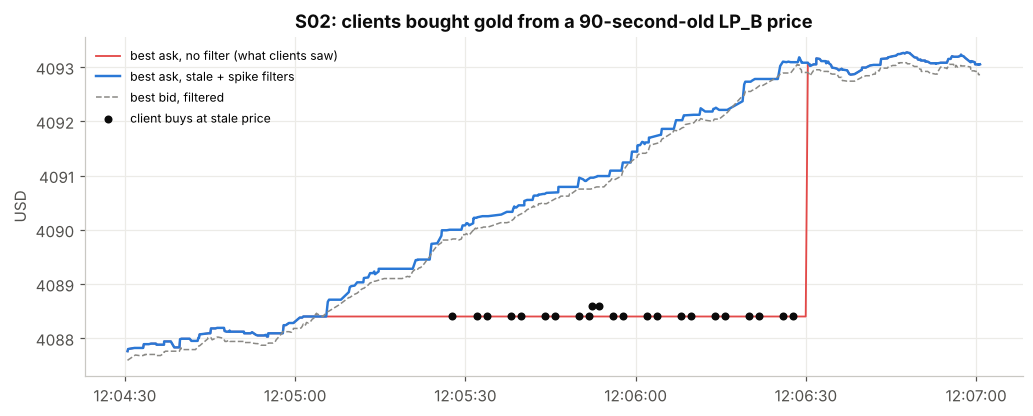

In [11]:
b0 = A.aggregated_book(quotes, "XAUUSD").loc["2025-10-15 12:04:30":"2025-10-15 12:07:00"]
b1 = fair["XAUUSD"].loc["2025-10-15 12:04:30":"2025-10-15 12:07:00"]
fig, ax = plt.subplots()
ax.plot(b0.index, b0.best_ask, color=P.ALERT, lw=1.2, label="best ask, no filter (what clients saw)")
ax.plot(b1.index, b1.best_ask, color=P.SERIES[0], lw=1.6, label="best ask, stale + spike filters")
ax.plot(b1.index, b1.best_bid, color=P.NEUTRAL, lw=1, ls="--", label="best bid, filtered")
s2 = suspicious[(suspicious.symbol == "XAUUSD")]
ax.scatter(s2.server_fill_time, s2.fill_price, color=P.INK, s=18, zorder=3, label="client buys at stale price")
ax.set_title("S02: clients bought gold from a 90-second-old LP_B price"); ax.set_ylabel("USD")
P.time_axis(ax, "%H:%M:%S"); ax.legend(loc="upper left", fontsize=8); plt.show()

With both filters, the deep crossed books (−50 pips) disappear, and every mispriced fill above would have been
executed at the fair price or rejected. The crossed updates that remain are brief and small: LPs updating a few
seconds apart in a moving market (mostly gold and the news minute). With real feeds (10+ updates/s) and a ~1 s stale
threshold they mostly vanish. A **crossed-book guard** (when bid > ask, drop the older of the two quotes) handles the rest.

## 6. Streaming smoothness
A good price stream is **regular**: no long freezes and no bursts of jumpy updates. Two quick metrics per LP:
* **Freeze ratio**: share of time the LP's quote is older than the stale threshold.
* **Tick-to-tick jump**: how far the mid moves between consecutive updates, in pips (p99.9). Spikes show up here.

In [12]:
smooth = []
for s in sym.index:
    st = lp_state(quotes, s)
    dt = st.index.to_series().diff().shift(-1).dt.total_seconds().fillna(0)
    for lp in A.LPS:
        q = quotes[(quotes.symbol == s) & (quotes.lp == lp)]
        jump = ((q.bid1 + q.ask1) / 2).diff().abs() / PIP[s]
        smooth.append(dict(symbol=s, lp=lp, freeze_pct=round(100 * dt[st[lp].age_ms > STALE_MS].sum() / dt.sum(), 2),
                           jump_p50=round(jump.median(), 2), jump_p999=round(jump.quantile(.999), 1),
                           max_jump=round(jump.max(), 1)))
pd.DataFrame(smooth).pivot(index="lp", columns="symbol")

freeze_pct               jump_p50               jump_p999               max_jump              
symbol     EURUSD GBPUSD XAUUSD   EURUSD GBPUSD XAUUSD    EURUSD GBPUSD XAUUSD   EURUSD GBPUSD XAUUSD
lp                                                                                                   
LP_A         0.12   0.09   0.12     0.05   0.05   0.25       0.5    0.8    3.8      8.1    6.8   17.8
LP_B         0.09   0.11   1.51     0.05   0.05   0.25       0.6    0.7    3.1      8.7    8.1   56.4
LP_C         2.29   2.27   2.32     0.05   0.05   0.25       0.5    0.6    4.3     50.0    7.0   29.7

## Incident cards
| | S01: bad tick | S02: stale feed |
|---|---|---|
| **Symptom** | one LP_C EURUSD quote ~50 pips off; crossed book for ~200 ms | LP_B gold quote unchanged for ~90 s while the market rallied; crossed book for 90 s |
| **Detected by** | deviation from the median of other LPs | quote age of the best price; LP-level per-symbol silence |
| **Impact** | B-book client filled ~50 pips through the market; A-book attempt rejected by LP last look | repeated B-book fills at stale prices (latency arbitrage) |
| **Root cause** | LP pricing error + **no spike filter** on the bridge | LP_B gold pricing engine froze, session still up + **no stale filter** |
| **Fix** | spike filter (deviation vs others, max jump vs own last) | per-symbol stale filter (age > N × normal interval) |
| **Follow-up** | request trade cancellation / price adjustment under the client agreement's manifest-error clause; LP incident report | review the arbitrage clients (Lesson 06); ask LP_B for an RCA; alert on per-symbol silence |

**Next:** Lesson 05, order routing and LP execution: fill ratios, last look, partial fills and re-routing.